Advanced Data Aggregator Project
Based on your Week 1 project (a simple API data extractor from JSONPlaceholder), I'll create a more difficult version to level up your data engineering skills. This new project builds on the original by incorporating both API calls and web scraping, making it more complex and real-world-like. It involves error handling, data validation, transformation, logging, file outputs, and a summary report—but now with multiple data sources, retries, and aggregation.
Project Overview: "User Profile Enricher"

Goal: Fetch user data from the JSONPlaceholder API, validate and transform it, then enrich each user's profile by:
Scraping additional info (e.g., city population) from Wikipedia using web scraping.
Making API calls to OpenWeatherMap to get current weather data for the user's city.

Why difficult?
Multiple integrations: API (JSONPlaceholder for users, OpenWeatherMap for weather) + web scraping (BeautifulSoup for Wikipedia).
Handle real-world issues: API rate limits, scraping variability (HTML changes), network errors with retries.
Data merging: Combine data from 3 sources per user.
Validation: Check for more fields, handle missing/invalid data.
Outputs: JSON, CSV, logs, and a detailed report.

Tech Stack: Python (requests for APIs/scraping, BeautifulSoup for parsing HTML, logging, json/csv modules). No external frameworks like Scrapy to keep it beginner-friendly but challenging.


Data_engineering_Journey/
├── .venv/                  # your virtual environment (don't touch)
├── .env                    # contains OPENWEATHER_API_KEY=yourkeyhere
├── user_enricher.py        # the main script (copy the code below)
├── user_enricher.log       # will be created when you run it
├── enriched_users.json     # output
└── enriched_users.csv      # output

In [25]:
import requests
from bs4 import BeautifulSoup
import json
import csv
import logging
import time
import os
from dotenv import load_dotenv
import pandas as pd

# Load API key from .env
load_dotenv()

# Setup logging (file + notebook output)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    handlers=[
        logging.FileHandler("enricher.log"),
        logging.StreamHandler()
    ]
)

print("Setup done")
print("API key present →", bool(os.environ.get("OPENWEATHER_API_KEY")))

Setup done
API key present → True


## Step 1 – Fetch users from JSONPlaceholder

In [26]:
def fetch_users():
    url = "https://jsonplaceholder.typicode.com/users"
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        users = r.json()
        logging.info(f"Successfully fetched {len(users)} users")
        return users
    except Exception as e:
        logging.error(f"Failed to fetch users: {e}")
        raise

# Execute
users = fetch_users()
print(f"Number of users: {len(users)}")
users[0]

2026-01-17 16:26:04,874 - INFO - Successfully fetched 10 users


Number of users: 10


{'id': 1,
 'name': 'Leanne Graham',
 'username': 'Bret',
 'email': 'Sincere@april.biz',
 'address': {'street': 'Kulas Light',
  'suite': 'Apt. 556',
  'city': 'Gwenborough',
  'zipcode': '92998-3874',
  'geo': {'lat': '-37.3159', 'lng': '81.1496'}},
 'phone': '1-770-736-8031 x56442',
 'website': 'hildegard.org',
 'company': {'name': 'Romaguera-Crona',
  'catchPhrase': 'Multi-layered client-server neural-net',
  'bs': 'harness real-time e-markets'}}

## Step 2 – Validate & extract needed fields

In [27]:
def clean_users(users):
    cleaned = []
    invalid = 0

    for user in users:
        try:
            record = {
                "id": user["id"],
                "name": user["name"],
                "email": user["email"],
                "city": user["address"]["city"],
                "phone": user["phone"],
            }
            cleaned.append(record)
        except KeyError:
            invalid += 1
            logging.warning(f"Invalid user record – missing fields (id: {user.get('id', '?')})")

    logging.info(f"Cleaned records: {len(cleaned)}   Invalid: {invalid}")
    return cleaned, invalid

cleaned_users, invalid_count = clean_users(users)

pd.DataFrame(cleaned_users)

2026-01-17 16:26:04,949 - INFO - Cleaned records: 10   Invalid: 0


,id,name,email,city,phone
0,1,Leanne Graham,Sincere@april.biz,Gwenborough,1-770-736-8031 x56442
1,2,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,010-692-6593 x09125
2,3,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,1-463-123-4447
3,4,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,493-170-9623 x156
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,(254)954-1289
5,6,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,1-477-935-8478 x6430
6,7,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,210.067.6132
7,8,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,586.493.6943 x140
8,9,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,(775)976-6794 x41206
9,10,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,024-648-3804


## Step 3 – Enrichment functions

In [28]:
def get_population(city):
    """Try to scrape population from Wikipedia infobox"""
    url = f"https://en.wikipedia.org/wiki/{city.replace(' ', '_')}"
    try:
        headers = {"User-Agent": "LearningProject/1.0"}
        r = requests.get(url, headers=headers, timeout=12)
        r.raise_for_status()

        soup = BeautifulSoup(r.text, "html.parser")
        infobox = soup.find("table", class_="infobox")

        if not infobox:
            return None

        for tr in infobox.find_all("tr"):
            th = tr.find("th")
            if th and "population" in th.text.lower():
                td = tr.find("td")
                if td:
                    text = td.get_text(strip=True).split()[0].replace(",", "")
                    if text.isdigit():
                        return int(text)
        return None

    except Exception as e:
        logging.debug(f"Population scrape failed for {city}: {str(e)[:80]}")
        return None
    
    
# Open Weather Map Temperature..... 
def get_temperature(city):
    api_key = os.environ.get("OPENWEATHER_API_KEY")
    if not api_key:
        raise ValueError("OPENWEATHER_API_KEY not found in .env")

    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"

    try:
        headers = {"User-Agent": "LearningProject/1.0"}
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()

        if data.get("cod") != 200:
            logging.info(f"Weather API: {data.get('message')} for {city}")
            return None

        return data["main"]["temp"]

    except Exception as e:
        logging.debug(f"Weather request failed for {city}: {str(e)[:80]}")
        return None


In [29]:
# City mapping: fake → real (for enrichment only)
city_mapping = {
    "Gwenborough": "Amsterdam",
    "Wisokyburgh": "Warsaw",
    "McKenziehaven": "London",
    "South Elvis": "Memphis",
    "Roscoeview": "New York",
    "South Christy": "Paris",
    "Howemouth": "Sydney",
    "Aliyaview": "Tokyo",
    "Bartholomebury": "Berlin",
    "Lebsackbury": "Rome"
}

print("Mapping used for real-world enrichment:")
for fake, real in city_mapping.items():
    print(f"  {fake:15} → {real}")

Mapping used for real-world enrichment:
  Gwenborough     → Amsterdam
  Wisokyburgh     → Warsaw
  McKenziehaven   → London
  South Elvis     → Memphis
  Roscoeview      → New York
  South Christy   → Paris
  Howemouth       → Sydney
  Aliyaview       → Tokyo
  Bartholomebury  → Berlin
  Lebsackbury     → Rome


In [30]:
## Step 4 – Enrich all records

In [31]:
def enrich(cleaned_users):
    enriched = []
    issues = []
    
    for record in cleaned_users:
        fake_city = record["city"]
        # Get the real city to use for API/scraping
        real_city = city_mapping.get(fake_city, fake_city)  # fallback = original if not mapped
        
        logging.info(f"Enriching user {record['id']} | {fake_city} → {real_city}")
        
        # Try to get population and temperature using the REAL city
        pop = get_population(real_city)
        temp = get_temperature(real_city)
        
        # Build the new record
        new_record = record.copy()
        new_record["original_city"] = fake_city           # keep fake name for reference
        new_record["enriched_from"] = real_city           # show which real city was used
        
        if pop is not None:
            new_record["population"] = pop
        else:
            new_record["population"] = None
        
        if temp is not None:
            new_record["temperature_c"] = temp
        else:
            new_record["temperature_c"] = None
        
        enriched.append(new_record)
        
        # Track what failed
        if pop is None or temp is None:
            issues.append(
                f"{real_city} (orig: {fake_city}, user {record['id']}): "
                f"pop={'missing' if pop is None else 'ok'}, "
                f"temp={'missing' if temp is None else 'ok'}"
            )
        
        time.sleep(1.2)  # polite delay between requests
    
    return enriched, issues

# Run enrichment
enriched_records, enrichment_issues = enrich(cleaned_users)

# Display the enriched data as a nice table
df_enriched = pd.DataFrame(enriched_records)
df_enriched

2026-01-17 16:26:05,231 - INFO - Enriching user 1 | Gwenborough → Amsterdam
2026-01-17 16:26:08,192 - INFO - Enriching user 2 | Wisokyburgh → Warsaw
2026-01-17 16:26:11,399 - INFO - Enriching user 3 | McKenziehaven → London
2026-01-17 16:26:14,688 - INFO - Enriching user 4 | South Elvis → Memphis
2026-01-17 16:26:16,460 - INFO - Enriching user 5 | Roscoeview → New York
2026-01-17 16:26:18,162 - INFO - Enriching user 6 | South Christy → Paris
2026-01-17 16:26:21,475 - INFO - Enriching user 7 | Howemouth → Sydney
2026-01-17 16:26:24,440 - INFO - Enriching user 8 | Aliyaview → Tokyo
2026-01-17 16:26:27,516 - INFO - Enriching user 9 | Bartholomebury → Berlin
2026-01-17 16:26:30,455 - INFO - Enriching user 10 | Lebsackbury → Rome


,id,name,email,city,phone,original_city,enriched_from,population,temperature_c
0,1,Leanne Graham,Sincere@april.biz,Gwenborough,1-770-736-8031 x56442,Gwenborough,Amsterdam,NaN,9.92
1,2,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,010-692-6593 x09125,Wisokyburgh,Warsaw,NaN,-3.63
2,3,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,1-463-123-4447,McKenziehaven,London,NaN,10.45
3,4,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,493-170-9623 x156,South Elvis,Memphis,NaN,3.69
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,(254)954-1289,Roscoeview,New York,NaN,3.08
5,6,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,1-477-935-8478 x6430,South Christy,Paris,2048472.0,11.72
6,7,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,210.067.6132,Howemouth,Sydney,NaN,19.69
7,8,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,586.493.6943 x140,Aliyaview,Tokyo,NaN,9.13
8,9,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,(775)976-6794 x41206,Bartholomebury,Berlin,NaN,1.87
9,10,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,024-648-3804,Lebsackbury,Rome,NaN,7.90


## Step 5 – Save results

In [32]:
def save(enriched_records):
    if not enriched_records:
        print("Nothing to save")
        return

    # JSON
    with open("enriched.json", "w", encoding="utf-8") as f:
        json.dump(enriched_records, f, indent=2, ensure_ascii=False)

    # CSV
    pd.DataFrame(enriched_records).to_csv("enriched.csv", index=False)

    print("Saved → enriched.json  &  enriched.csv")

save(enriched_records)

Saved → enriched.json  &  enriched.csv


## Step 6 – Summary

In [34]:
total = len(users)
valid = len(cleaned_users)
enriched_count = len(enriched_records)
temp_success = sum(1 for r in enriched_records if r.get("temperature_c") is not None)
pop_success = sum(1 for r in enriched_records if r.get("population") is not None)

temp_pct = (temp_success / valid * 100) if valid > 0 else 0
pop_pct   = (pop_success   / valid * 100) if valid > 0 else 0

print("═" * 70)
print("                    SUMMARY REPORT")
print("═" * 70)
print(f"Total users fetched         : {total}")
print(f"Valid after cleaning        : {valid}")
print(f"Invalid/skipped records     : {invalid_count}")
print(f"Enriched records            : {enriched_count}")
print(f"With temperature data       : {temp_success} ({temp_pct:.1f}%)")
print(f"With population data        : {pop_success}   ({pop_pct:.1f}%)")
print(f"Enrichment issues           : {len(enrichment_issues)}")
print("\nIssues found:")
if enrichment_issues:
    for issue in enrichment_issues:
        print(f"  • {issue}")
else:
    print("  None — all enrichments successful!")
print("═" * 70)

# Optional: show the table again
df_enriched

══════════════════════════════════════════════════════════════════════
                    SUMMARY REPORT
══════════════════════════════════════════════════════════════════════
Total users fetched         : 10
Valid after cleaning        : 10
Invalid/skipped records     : 0
Enriched records            : 10
With temperature data       : 10 (100.0%)
With population data        : 1   (10.0%)
Enrichment issues           : 9

Issues found:
  • Amsterdam (orig: Gwenborough, user 1): pop=missing, temp=ok
  • Warsaw (orig: Wisokyburgh, user 2): pop=missing, temp=ok
  • London (orig: McKenziehaven, user 3): pop=missing, temp=ok
  • Memphis (orig: South Elvis, user 4): pop=missing, temp=ok
  • New York (orig: Roscoeview, user 5): pop=missing, temp=ok
  • Sydney (orig: Howemouth, user 7): pop=missing, temp=ok
  • Tokyo (orig: Aliyaview, user 8): pop=missing, temp=ok
  • Berlin (orig: Bartholomebury, user 9): pop=missing, temp=ok
  • Rome (orig: Lebsackbury, user 10): pop=missing, temp=ok
════════

,id,name,email,city,phone,original_city,enriched_from,population,temperature_c
0,1,Leanne Graham,Sincere@april.biz,Gwenborough,1-770-736-8031 x56442,Gwenborough,Amsterdam,NaN,9.92
1,2,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,010-692-6593 x09125,Wisokyburgh,Warsaw,NaN,-3.63
2,3,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,1-463-123-4447,McKenziehaven,London,NaN,10.45
3,4,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,493-170-9623 x156,South Elvis,Memphis,NaN,3.69
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,(254)954-1289,Roscoeview,New York,NaN,3.08
5,6,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,1-477-935-8478 x6430,South Christy,Paris,2048472.0,11.72
6,7,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,210.067.6132,Howemouth,Sydney,NaN,19.69
7,8,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,586.493.6943 x140,Aliyaview,Tokyo,NaN,9.13
8,9,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,(775)976-6794 x41206,Bartholomebury,Berlin,NaN,1.87
9,10,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,024-648-3804,Lebsackbury,Rome,NaN,7.90


In [ ]:
# A SECOND VERSION FOR THE SAME TUTORIAL 

In [46]:
import requests
from bs4 import BeautifulSoup
import json
import logging
import time
import os
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt  # for visualization

# Load API key
load_dotenv()

# Logging setup (file + output)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-7s  %(message)s',
    handlers=[logging.FileHandler("enricher_large.log"), logging.StreamHandler()]
)

print("Setup done")
print("API key present →", bool(os.environ.get("OPENWEATHER_API_KEY")))


# Fetch users from RandomUser.me (5000 records)

def fetch_users(num_users=500):
    url = f"https://randomuser.me/api/?results={num_users}"
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        data = r.json()["results"]
        logging.info(f"Fetched {len(data)} users")
        return data
    except Exception as e:
        logging.error(f"Fetch failed: {e}")
        raise

# Execute
users = fetch_users(500)
print(f"Number of users: {len(users)}")
users[0]



Setup done
API key present → True


2026-01-17 17:25:25,736 - INFO - Fetched 500 users


Number of users: 500


{'gender': 'male',
 'name': {'title': 'Mr', 'first': 'Blake', 'last': 'Parker'},
 'location': {'street': {'number': 4856, 'name': "O'Connell Avenue"},
  'city': 'Thurles',
  'state': 'Sligo',
  'country': 'Ireland',
  'postcode': 57055,
  'coordinates': {'latitude': '1.6461', 'longitude': '-51.4974'},
  'timezone': {'offset': '-8:00',
   'description': 'Pacific Time (US & Canada)'}},
 'email': 'blake.parker@example.com',
 'login': {'uuid': '1b278dc8-c0db-439b-a0cb-fad477a164bc',
  'username': 'silverpanda998',
  'password': '0987',
  'salt': 'Wc2RlLSy',
  'md5': '5cff96973e0693b95417298b4bc03743',
  'sha1': 'ad7bb05fbaf8d2128f31cdf39a673cbbd4bc562e',
  'sha256': 'bb64f1e712e6ebc3a4fd9605189de1dec62648368ee903fe87ab69c9ae17391e'},
 'dob': {'date': '1980-04-05T12:35:19.471Z', 'age': 45},
 'registered': {'date': '2019-09-02T23:15:09.428Z', 'age': 6},
 'phone': '041-460-4277',
 'cell': '081-147-1596',
 'id': {'name': 'PPS', 'value': '9683676T'},
 'picture': {'large': 'https://randomuser.me

In [47]:
## Step 2 – Clean & extract fields (adapt to RandomUser format)

def clean_users(users):
    cleaned = []
    invalid = 0

    for user in users:
        try:
            record = {
                "id": user["login"]["uuid"],  # unique ID
                "name": f"{user['name']['first']} {user['name']['last']}",
                "email": user["email"],
                "city": user["location"]["city"],
                "country": user["location"]["country"],
                "age": user["dob"]["age"]
            }
            cleaned.append(record)
        except KeyError:
            invalid += 1
            logging.warning(f"Invalid user record")

    logging.info(f"Cleaned: {len(cleaned)}  Invalid: {invalid}")
    return pd.DataFrame(cleaned), invalid  # return as DataFrame for easy manipulation

# Execute
df_cleaned, invalid_count = clean_users(users)
df_cleaned.head(10)  # show sample


2026-01-17 17:25:38,160 - INFO - Cleaned: 500  Invalid: 0


,id,name,email,city,country,age
0,1b278dc8-c0db-439b-a0cb-fad477a164bc,Blake Parker,blake.parker@example.com,Thurles,Ireland,45
1,b28eaead-5aba-4e97-890b-ef6a2ceec3fe,Gonca Demirbaş,gonca.demirbas@example.com,Osmaniye,Turkey,79
2,9f0f53ed-8694-43ae-aba4-2fd4288929f9,Bharathy Nair,bharathy.nair@example.com,Haldia,India,44
3,57d00d70-da8e-4b4d-ab5f-79fa6ab374f4,Frede Castro,frede.castro@example.com,Curitiba,Brazil,63
4,e84282df-e827-4ec0-9900-620e44f962fc,Fletcher Morris,fletcher.morris@example.com,Wellington,New Zealand,41
5,7f3b4355-b76a-4658-ab46-d74493f3afae,Jason Daniels,jason.daniels@example.com,Baton Rouge,United States,50
6,6b4c5c3c-4583-4e9e-b00a-9310dcfeb4bb,Fatma Abanuz,fatma.abanuz@example.com,Nevşehir,Turkey,61
7,5a6fd0a3-f9c7-452f-9d1a-f0736db1e98c,Veera Kivisto,veera.kivisto@example.com,Kannus,Finland,58
8,0c32b12d-8dc5-47c8-98ed-d608b6229ee6,Jared Bishop,jared.bishop@example.com,Newcastle upon Tyne,United Kingdom,38
9,b230a5bf-ae7f-4391-a1c7-debdfde86007,Jonathan León,jonathan.leon@example.com,Elche,Spain,62


In [48]:
## Step 3 – Enrichment functions (same as before)

def get_population(city):
    url = f"https://en.wikipedia.org/wiki/{city.replace(' ', '_')}"
    try:
        headers = {"User-Agent": "LearningProject/1.0"}
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, "html.parser")
        infobox = soup.find("table", class_="infobox")
        if not infobox:
            return None
        for tr in infobox.find_all("tr"):
            th = tr.find("th")
            if th and "population" in th.text.lower():
                td = tr.find("td")
                if td:
                    text = td.text.strip().split()[0].replace(",", "")
                    if text.isdigit():
                        return int(text)
        return None
    except Exception as e:
        logging.debug(f"Population failed for {city}: {e}")
        return None
    
def get_temperature(city):
    api_key = os.environ.get("OPENWEATHER_API_KEY")
    if not api_key:
        raise ValueError("Missing OPENWEATHER_API_KEY")
    
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    try:
        headers = {"User-Agent": "LearningProject/1.0"}
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()
        if data.get("cod") != 200:
            logging.info(f"Weather error: {data.get('message')} for {city}")
            return None
        return data["main"]["temp"]
    except Exception as e:
        logging.debug(f"Temperature failed for {city}: {e}")
        return None

In [49]:
## Step 4 – Enrich the DataFrame
def enrich_df(df):
    df["population"] = None
    df["temperature_c"] = None
    issues = []

    for idx, row in df.iterrows():
        city = row["city"]
        pop = get_population(city)
        temp = get_temperature(city)
        
        df.at[idx, "population"] = pop
        df.at[idx, "temperature_c"] = temp
        
        if pop is None or temp is None:
            issues.append(f"{city} (id {row['id'][:8]}...): pop={pop is None}, temp={temp is None}")
        
        time.sleep(1.2)  # delay to avoid rate limits
    
    return df, issues

# Execute (this will run for ~10 minutes – 500 rows x 1.2s)
df_enriched, enrichment_issues = enrich_df(df_cleaned)

df_enriched.head(10)  # sample

,id,name,email,city,country,age,population,temperature_c
0,1b278dc8-c0db-439b-a0cb-fad477a164bc,Blake Parker,blake.parker@example.com,Thurles,Ireland,45,None,5.78
1,b28eaead-5aba-4e97-890b-ef6a2ceec3fe,Gonca Demirbaş,gonca.demirbas@example.com,Osmaniye,Turkey,79,252186,5.48
2,9f0f53ed-8694-43ae-aba4-2fd4288929f9,Bharathy Nair,bharathy.nair@example.com,Haldia,India,44,None,19.18
3,57d00d70-da8e-4b4d-ab5f-79fa6ab374f4,Frede Castro,frede.castro@example.com,Curitiba,Brazil,63,None,28.17
4,e84282df-e827-4ec0-9900-620e44f962fc,Fletcher Morris,fletcher.morris@example.com,Wellington,New Zealand,41,None,13.1
5,7f3b4355-b76a-4658-ab46-d74493f3afae,Jason Daniels,jason.daniels@example.com,Baton Rouge,United States,50,None,10.73
6,6b4c5c3c-4583-4e9e-b00a-9310dcfeb4bb,Fatma Abanuz,fatma.abanuz@example.com,Nevşehir,Turkey,61,128290,-6.44
7,5a6fd0a3-f9c7-452f-9d1a-f0736db1e98c,Veera Kivisto,veera.kivisto@example.com,Kannus,Finland,58,None,1.35
8,0c32b12d-8dc5-47c8-98ed-d608b6229ee6,Jared Bishop,jared.bishop@example.com,Newcastle upon Tyne,United Kingdom,38,None,7.09
9,b230a5bf-ae7f-4391-a1c7-debdfde86007,Jonathan León,jonathan.leon@example.com,Elche,Spain,62,None,13.28


## Step 5 – Manipulate the data (new! Filter, aggregate, visualize)


European users: 122


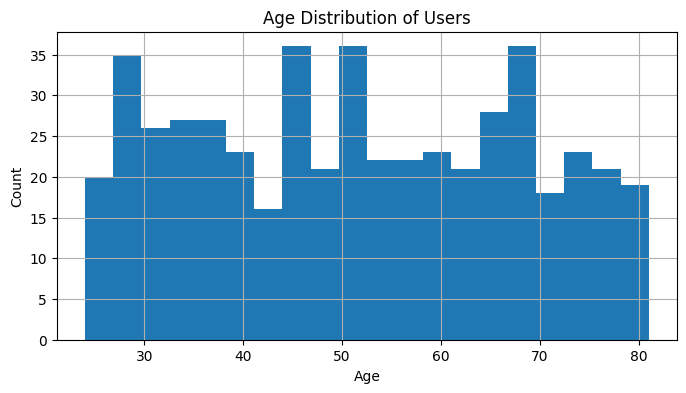

In [50]:
# Filter example: Only European countries (you can add more)
europe_countries = ["Netherlands", "Germany", "France", "Spain", "Italy", "United Kingdom"]
df_europe = df_enriched[df_enriched["country"].isin(europe_countries)]
print(f"European users: {len(df_europe)}")

# Aggregate example: Avg temperature and population by country
agg = df_enriched.groupby("country").agg({
    "temperature_c": "mean",
    "population": "mean",
    "age": "mean"
}).dropna()  # drop if no enrichment
agg.rename(columns={"temperature_c": "avg_temp_c", "population": "avg_pop", "age": "avg_age"}, inplace=True)
agg.head(10)  # show

# Visualize example: Histogram of ages
plt.figure(figsize=(8, 4))
df_enriched["age"].hist(bins=20)
plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [51]:
## Step 6 – Save results
def save(df):
    if df.empty:
        print("Nothing to save")
        return
    df.to_json("enriched_large.json", orient="records", indent=2)
    df.to_csv("enriched_large.csv", index=False)
    print("Saved → enriched_large.json & .csv")

save(df_enriched)


Saved → enriched_large.json & .csv


In [52]:
## Step 7 – Summary Report
total = len(users)
valid = len(df_cleaned)
temp_success = df_enriched["temperature_c"].notna().sum()
pop_success = df_enriched["population"].notna().sum()

print("═" * 70)
print("                    SUMMARY REPORT")
print("═" * 70)
print(f"Total fetched               : {total}")
print(f"Valid after cleaning        : {valid}")
print(f"Invalid records             : {invalid_count}")
print(f"With temperature            : {temp_success} ({(temp_success/valid*100 if valid>0 else 0):.1f}%)")
print(f"With population             : {pop_success} ({(pop_success/valid*100 if valid>0 else 0):.1f}%)")
print(f"Enrichment issues           : {len(enrichment_issues)}")
if enrichment_issues:
    print("\nSample issues (first 5):")
    for issue in enrichment_issues[:5]:
        print(f"  • {issue}")
else:
    print("  No issues!")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
                    SUMMARY REPORT
══════════════════════════════════════════════════════════════════════
Total fetched               : 500
Valid after cleaning        : 500
Invalid records             : 0
With temperature            : 453 (90.6%)
With population             : 51 (10.2%)
Enrichment issues           : 450

Sample issues (first 5):
  • Thurles (id 1b278dc8...): pop=True, temp=False
  • Haldia (id 9f0f53ed...): pop=True, temp=False
  • Curitiba (id 57d00d70...): pop=True, temp=False
  • Wellington (id e84282df...): pop=True, temp=False
  • Baton Rouge (id 7f3b4355...): pop=True, temp=False
══════════════════════════════════════════════════════════════════════
